<!-- reader-content -->

# Differentiability

Start with a scalar loss through statics, pass the same pattern through one
driven sequence, then combine several experiments in a joint loss.

## Losses through statics

A scalar loss has a gradient. A vector residual has a Jacobian. Both pass
through the same public `Chip.with_params()` call.

The second observable uses the sigma-z convention
$\chi_{\sigma_z}=\mathrm{dispersive\_shift}/2$. The scalar method returns the
full pull $E_{11}-E_{10}-E_{01}+E_{00}$.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from quchip import Capacitive, Chip, DuffingTransmon, Resonator
from quchip.backend.dynamiqs import DynamiqsBackend

q = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=4, label="q")
r = Resonator(freq=7.0, levels=4, label="r")
chip = Chip(
    [q, r],
    [Capacitive(q, r, g=0.05, label="qr")],
    frame="rotating",
    backend=DynamiqsBackend(),
)

names = ["q.freq", "q.anharmonicity", "qr.g"]
theta = jnp.array([5.0, -0.25, 0.05])
target = jnp.array([5.05, -0.0010])


def observables(th):
    c = chip.with_params(dict(zip(names, th)))
    chi_sigma_z = c.dispersive_shift("q", "r") / 2
    return jnp.stack([jnp.asarray(c.freq("q")), jnp.asarray(chi_sigma_z)])


def residual(th):
    return observables(th) - target


def loss(th):
    return jnp.sum(residual(th) ** 2)


static_gradient = jax.grad(loss)(theta)
static_jacobian = jax.jacrev(residual)(theta)

{
    "observables_f01_chi_sigma_z": observables(theta),
    "gradient_shape": static_gradient.shape,
    "jacobian_shape": static_jacobian.shape,
}

{'observables_f01_chi_sigma_z': Array([ 4.99853347e+00, -1.43010024e-04], dtype=float64),
 'gradient_shape': (3,),
 'jacobian_shape': (2, 3)}

<!-- executed-output:start -->

Output:

```text
{'observables_f01_chi_sigma_z': Array([ 4.99853347e+00, -1.43010024e-04], dtype=float64),
 'gradient_shape': (3,),
 'jacobian_shape': (2, 3)}
```

<!-- executed-output:end -->

The parameter vector mixes GHz-scale frequencies and a smaller coupling. For
optimization, work in dimensionless coordinates such as fractional frequency
changes or MHz-scale offsets. The gradient then measures comparable design
moves instead of inheriting the arbitrary numerical size of each unit.

Sweep the coupling around the evaluation point, then draw the tangent predicted
by the corresponding Jacobian column. The derivative is the tangent's slope;
its departure from the full curve shows that it is a local statement.

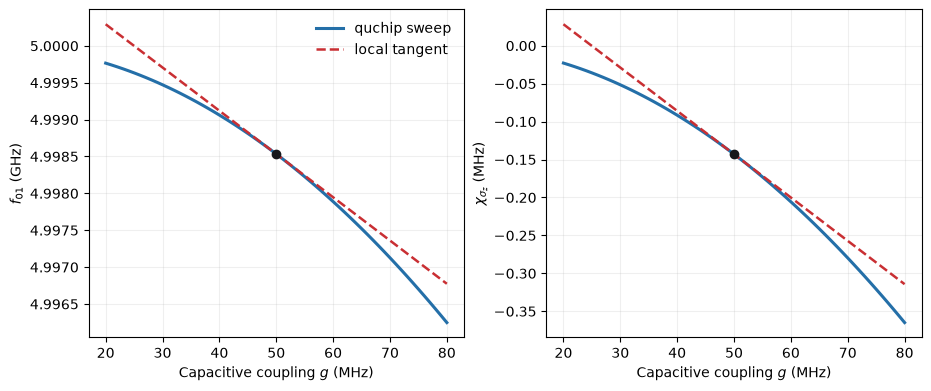

In [2]:
coupling_values = jnp.linspace(0.02, 0.08, 61)
observable_sweep = jax.vmap(
    lambda coupling: observables(theta.at[2].set(coupling))
)(coupling_values)
coupling_tangent = observables(theta) + (
    coupling_values[:, None] - theta[2]
) * static_jacobian[:, 2]

static_figure, static_axes = plt.subplots(1, 2, figsize=(9.2, 3.8), layout="constrained")
for observable_index, (axis, ylabel, scale) in enumerate(
    zip(
        static_axes,
        (r"$f_{01}$ (GHz)", r"$\chi_{\sigma_z}$ (MHz)"),
        (1.0, 1.0e3),
        strict=True,
    )
):
    axis.plot(
        1.0e3 * coupling_values,
        scale * observable_sweep[:, observable_index],
        color="#246FA8",
        linewidth=2.2,
        label="quchip sweep",
    )
    axis.plot(
        1.0e3 * coupling_values,
        scale * coupling_tangent[:, observable_index],
        color="#C92F33",
        linestyle="--",
        linewidth=1.8,
        label="local tangent",
    )
    axis.plot(
        1.0e3 * theta[2],
        scale * observables(theta)[observable_index],
        marker="o",
        color="#16181C",
        linestyle="none",
    )
    axis.set(xlabel=r"Capacitive coupling $g$ (MHz)", ylabel=ylabel)
    axis.grid(alpha=0.2)

static_axes[0].legend(frameon=False)

static_figure_path = "../docs/images/differentiate_static_slope.png"
static_figure.savefig(static_figure_path, dpi=180)
plt.show()

```{figure} ../images/differentiate_static_slope.png
:width: 760px
:alt: Qubit frequency and dispersive shift swept over capacitive coupling with local tangent lines at 50 megahertz

The black point is where `jax.jacrev` evaluates the slope. The dispersive shift
bends away from its tangent faster than $f_{01}$ over this range.
```

## Fit experimental statics

Stefanski *et al.* fitted a fluxonium spectrum to obtain $E_C$, $E_J$, and
$E_L$. Their [paper](https://arxiv.org/abs/2411.13437) and
[analysis repository](https://github.com/AndersenQubitLab/FPA-RO-experimental)
publish the extracted frequencies and fitted parameters. Here we start away
from those parameters and minimize a differentiable quchip loss.

Every eighth measurement enters the fit. The intervening points remain held
out, and the plotted model uses its own 351-point flux grid.

In [3]:
import csv
import io
import json
from urllib.request import urlopen

from scipy.optimize import minimize

from quchip import Fluxonium

paper_data_root = (
    "https://raw.githubusercontent.com/AndersenQubitLab/"
    "FPA-RO-experimental/57dc268dd048d1372db082c3ddd97a04871580bf"
)

with urlopen(f"{paper_data_root}/processed_data_fx8.csv") as response:  # noqa: S310
    spectrum_rows = list(
        csv.DictReader(io.StringIO(response.read().decode("utf-8")))
    )

published_values = np.asarray(
    [float(spectrum_rows[index]["energy_params"]) for index in range(5)]
)
published_energies = published_values[[3, 2, 4]]  # E_C, E_J, E_L

measured_flux_all = np.asarray(
    [float(row["phi_ext_qubit"]) for row in spectrum_rows if row["phi_ext_qubit"]]
)
measured_f01_all = np.asarray(
    [float(row["qubit_freq"]) for row in spectrum_rows if row["qubit_freq"]]
)
paper_window = measured_flux_all <= 0.85
measured_flux = measured_flux_all[paper_window]
measured_f01 = measured_f01_all[paper_window]

training_indices = np.arange(0, measured_flux.size, 8)
holdout_mask = np.ones(measured_flux.size, dtype=bool)
holdout_mask[training_indices] = False
training_flux = jnp.asarray(measured_flux[training_indices])
training_f01 = jnp.asarray(measured_f01[training_indices])

The optimization model uses a 160-point phase grid. Logarithmic coordinates
keep the three circuit energies positive and put them on comparable numerical
scales.

In [4]:
fit_q = Fluxonium(
    E_C=0.72,
    E_J=4.4,
    E_L=0.68,
    phi_ext=0.5,
    levels=4,
    num_basis=160,
    phi_max=5.0 * np.pi,
    basis="eigen",
    label="q",
)
fit_chip = Chip(
    [fit_q],
    [],
    basis="eigen",
    frame="lab",
    backend=DynamiqsBackend(),
)

energy_scale = jnp.asarray([1.0, 4.0, 1.0])
initial_energies = np.asarray([0.72, 4.4, 0.68])
initial_coordinates = jnp.log(jnp.asarray(initial_energies) / energy_scale)


def energies_from_coordinates(coordinates):
    return energy_scale * jnp.exp(coordinates)


def fluxonium_f01(energies, phi_ext):
    point = fit_chip.with_params(
        {
            "q.E_C": energies[0],
            "q.E_J": energies[1],
            "q.E_L": energies[2],
            "q.phi_ext": phi_ext,
        }
    )
    return point.freq("q")


def spectrum_prediction(coordinates, flux):
    energies = energies_from_coordinates(coordinates)
    return jax.vmap(lambda phi: fluxonium_f01(energies, phi))(flux)


def pseudo_huber(residual):
    return 2.0 * (jnp.sqrt(1.0 + residual**2) - 1.0)


def experimental_loss(coordinates):
    residual_mhz = 1.0e3 * (
        spectrum_prediction(coordinates, training_flux) - training_f01
    )
    return jnp.mean(pseudo_huber(residual_mhz / 3.0))


initial_loss, initial_gradient = jax.value_and_grad(experimental_loss)(
    initial_coordinates
)
{
    "training_points": len(training_indices),
    "holdout_points": int(holdout_mask.sum()),
    "initial_loss": initial_loss,
    "initial_gradient": initial_gradient,
}

{'training_points': 20,
 'holdout_points': 133,
 'initial_loss': Array(69.1958024, dtype=float64),
 'initial_gradient': Array([-172.56931354, -330.94152066, -487.32690024], dtype=float64)}

<!-- executed-output:start -->

Output:

```text
{'training_points': 20,
 'holdout_points': 133,
 'initial_loss': Array(69.1958024, dtype=float64),
 'initial_gradient': Array([-172.56931354, -330.94152066, -487.32690024], dtype=float64)}
```

<!-- executed-output:end -->

SciPy supplies bounded optimizer control. JAX supplies the loss and its exact
gradient at every iteration.

In [5]:
compiled_loss_and_gradient = jax.jit(jax.value_and_grad(experimental_loss))
loss_history = []


def scipy_objective(coordinates):
    value, gradient = compiled_loss_and_gradient(jnp.asarray(coordinates))
    return float(value), np.asarray(gradient, dtype=float)


fit = minimize(
    scipy_objective,
    np.asarray(initial_coordinates),
    method="L-BFGS-B",
    jac=True,
    bounds=[
        (np.log(0.3), np.log(1.5)),
        (np.log(2.0 / 4.0), np.log(6.0 / 4.0)),
        (np.log(0.3), np.log(1.5)),
    ],
    callback=lambda coordinates: loss_history.append(
        scipy_objective(coordinates)[0]
    ),
    options={"maxiter": 160, "ftol": 1.0e-12, "gtol": 1.0e-9},
)

recovered_energies = np.asarray(
    energies_from_coordinates(jnp.asarray(fit.x)),
    dtype=float,
)

Evaluation starts from a new 351-point model grid. After that forward
calculation, interpolation places the model at the held-out measurement
coordinates for the residual check.

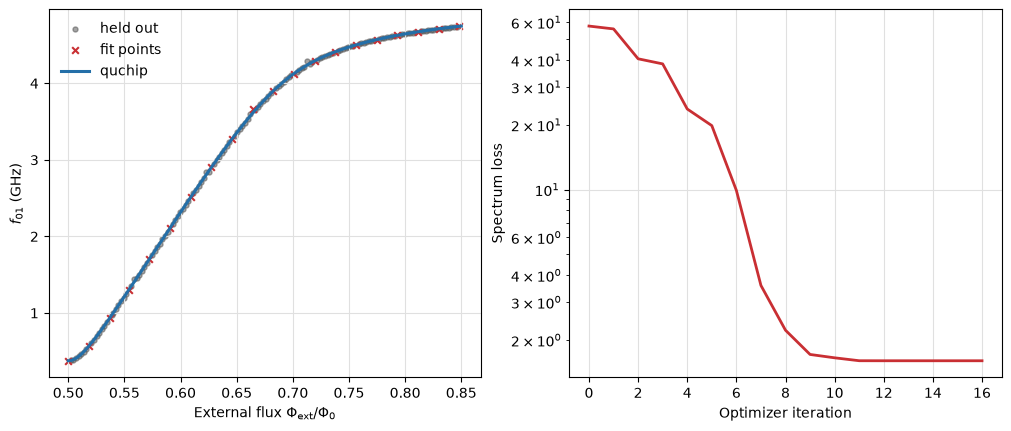

In [6]:
model_flux = jnp.linspace(0.5, 0.85, 351)
model_f01 = np.asarray(spectrum_prediction(jnp.asarray(fit.x), model_flux))
predicted_at_measurements = np.interp(
    measured_flux,
    np.asarray(model_flux),
    model_f01,
)
holdout_residual_mhz = 1.0e3 * (
    predicted_at_measurements[holdout_mask] - measured_f01[holdout_mask]
)

fit_figure, (fit_axis, history_axis) = plt.subplots(
    1,
    2,
    figsize=(10.0, 4.2),
    layout="constrained",
)
fit_axis.scatter(
    measured_flux[holdout_mask],
    measured_f01[holdout_mask],
    s=13,
    color="0.35",
    alpha=0.55,
    label="held out",
)
fit_axis.scatter(
    measured_flux[training_indices],
    measured_f01[training_indices],
    s=23,
    color="#C92F33",
    marker="x",
    label="fit points",
)
fit_axis.plot(model_flux, model_f01, color="#246FA8", linewidth=2.2, label="quchip")
fit_axis.set(
    xlabel=r"External flux $\Phi_{\mathrm{ext}}/\Phi_0$",
    ylabel=r"$f_{01}$ (GHz)",
)
fit_axis.legend(frameon=False)
fit_axis.grid(color="0.88")

history_axis.semilogy(loss_history, color="#C92F33", linewidth=2.0)
history_axis.set(xlabel="Optimizer iteration", ylabel="Spectrum loss")
history_axis.grid(color="0.88")

experimental_fit_path = "../docs/images/differentiate_fluxonium_fit.png"
fit_figure.savefig(experimental_fit_path, dpi=180)
plt.show()

```{figure} ../images/differentiate_fluxonium_fit.png
:width: 760px
:alt: Fluxonium spectrum fitted on sparse experimental points with held-out measurements and convergence history

Twenty measurements determine the loss. The remaining 133 points test the
recovered spectrum.
```

In [7]:
experimental_fit_receipt = {
    "fit_success": bool(fit.success),
    "iterations": int(fit.nit),
    "training_points": len(training_indices),
    "holdout_points": int(holdout_mask.sum()),
    "published_E_C_E_J_E_L": published_energies.tolist(),
    "initial_E_C_E_J_E_L": initial_energies.tolist(),
    "recovered_E_C_E_J_E_L": recovered_energies.tolist(),
    "relative_parameter_error": (
        (recovered_energies - published_energies) / published_energies
    ).tolist(),
    "holdout_median_absolute_error_mhz": float(
        np.median(np.abs(holdout_residual_mhz))
    ),
    "holdout_rmse_mhz": float(np.sqrt(np.mean(holdout_residual_mhz**2))),
}

print(
    "RESULT experimental_statics="
    + json.dumps(experimental_fit_receipt, sort_keys=True, separators=(",", ":"))
)

RESULT experimental_statics={"fit_success":true,"holdout_median_absolute_error_mhz":0.8806134062853133,"holdout_points":133,"holdout_rmse_mhz":6.967105516086113,"initial_E_C_E_J_E_L":[0.72,4.4,0.68],"iterations":17,"published_E_C_E_J_E_L":[0.8652719648666846,3.8217399868188027,0.8215798519627777],"recovered_E_C_E_J_E_L":[0.8704199128839734,3.820362983228374,0.8208603168362569],"relative_parameter_error":[0.005949514402771569,-0.0003603080259719065,-0.0008757945132196185],"training_points":20}


<!-- executed-output:start -->

Output:

```text
RESULT experimental_statics={"fit_success":true,"holdout_median_absolute_error_mhz":0.8806134062853133,"holdout_points":133,"holdout_rmse_mhz":6.967105516086113,"initial_E_C_E_J_E_L":[0.72,4.4,0.68],"iterations":17,"published_E_C_E_J_E_L":[0.8652719648666846,3.8217399868188027,0.8215798519627777],"recovered_E_C_E_J_E_L":[0.8704199128839734,3.820362983228374,0.8208603168362569],"relative_parameter_error":[0.005949514402771569,-0.0003603080259719065,-0.0008757945132196185],"training_points":20}
```

<!-- executed-output:end -->

The recovered circuit energies are within $0.6\%$ of the authors' values. The
few large spectroscopy residuals remain in the holdout RMSE; the median error
is $0.88$ MHz. This section fits the isolated fluxonium spectrum. The paper's
full fit also included the coupled readout resonator.

## Losses through simple dynamics

This section differentiates the final excited-state population with respect to
pulse amplitude, Gaussian shape, and detuning.

The dynamiqs backend keeps these declared parameters differentiable through
the time-domain solve. Install it with `pip install 'quchip[dynamiqs]'`.

In [8]:
import json

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from quchip import RWA, ChargeDrive, Chip, DuffingTransmon, Gaussian, QuantumSequence

amplitude0 = 0.029
frequency0 = 5.0
sigmas0 = 3.0

qubit = DuffingTransmon(
    freq=frequency0,
    anharmonicity=-0.30,
    levels=3,
    label="q",
)
chip = Chip(
    [qubit],
    frame="rotating",
    approximation=RWA(),
    backend="dynamiqs",
)
drive = ChargeDrive(qubit, label="xy")
chip.wire(drive)

sequence = QuantumSequence(chip)
sequence.schedule(
    drive,
    envelope=Gaussian(duration=40.0, sigmas=sigmas0, amplitude=amplitude0),
    freq=frequency0,
)
times = jnp.linspace(0.0, 60.0, 121)

One unit in the perturbation vector means $1\%$ in pulse amplitude, $1\%$ in
the Gaussian parameter $N_\sigma$, or $1$ MHz in pulse detuning. quchip defines
$\sigma=\mathrm{duration}/(2N_\sigma)$, so increasing $N_\sigma$ by $1\%$
narrows the physical Gaussian width by about $1\%$. The derivatives predict
changes in final population on these three scales.

`with_params()` returns a rebound sequence. It does not mutate the declared
sequence.

In [9]:
parameter_paths = ("pulse.0.amplitude", "pulse.0.sigmas", "pulse.0.freq")
perturbation_labels = (
    "amplitude (+1%)",
    r"$N_\sigma$ (+1%; $\sigma$ -1%)",
    "detuning (+1 MHz)",
)


def final_population(perturbation):
    rebound = sequence.with_params(
        {
            "pulse.0.amplitude": amplitude0 * (1.0 + 0.01 * perturbation[0]),
            "pulse.0.sigmas": sigmas0 * (1.0 + 0.01 * perturbation[1]),
            "pulse.0.freq": frequency0 + perturbation[2] * 1.0e-3,
        }
    )
    result = rebound.simulate(
        tlist=times,
        initial_state={"q": 0},
        check_truncation=False,
        partition=False,
    )
    return jnp.real(result.population("q", level=1)[-1])

The output is one scalar. `jax.grad` returns one derivative for each input,
while `jax.value_and_grad` evaluates the population and its gradient together.

In [10]:
origin = jnp.zeros(3)
population0, gradient = jax.jit(jax.value_and_grad(final_population))(origin)
target_population = jnp.asarray(0.995)


def dynamic_loss(perturbation):
    return (final_population(perturbation) - target_population) ** 2


loss0, loss_gradient = jax.jit(jax.value_and_grad(dynamic_loss))(origin)

{
    "population": population0,
    "population_gradient": gradient,
    "loss": loss0,
    "loss_gradient": loss_gradient,
}

{'population': Array(0.99551809, dtype=float64),
 'population_gradient': Array([ 0.00157614, -0.00156723,  0.00337811], dtype=float64),
 'loss': Array(2.68420188e-07, dtype=float64),
 'loss_gradient': Array([ 1.63317434e-06, -1.62394008e-06,  3.50034612e-06], dtype=float64)}

<!-- executed-output:start -->

Output:

```text
{'population': Array(0.99551809, dtype=float64),
 'population_gradient': Array([ 0.00157614, -0.00156723,  0.00337811], dtype=float64),
 'loss': Array(2.68420188e-07, dtype=float64),
 'loss_gradient': Array([ 1.63317434e-06, -1.62394008e-06,  3.50034612e-06], dtype=float64)}
```

<!-- executed-output:end -->

At this operating point, increasing amplitude or detuning raises the final
population; narrowing the Gaussian lowers it.

### Check the result

Automatic differentiation should agree with a numerical derivative, but a
single finite-difference step can agree accidentally. We halve the step four
times and check convergence for every parameter.

In [11]:
steps = jnp.asarray([0.5, 0.25, 0.125, 0.0625, 0.03125])
directions = jnp.eye(3)


@jax.jit
def central_differences(step):
    return jax.vmap(
        lambda direction: (
            final_population(step * direction) - final_population(-step * direction)
        )
        / (2.0 * step)
    )(directions)


finite_differences = jnp.stack([central_differences(step) for step in steps])
relative_errors = jnp.abs(finite_differences - gradient) / jnp.maximum(jnp.abs(gradient), 1.0e-12)

The upper panel compares the predicted population changes with central finite
differences. The lower panel plots their relative error across step sizes.

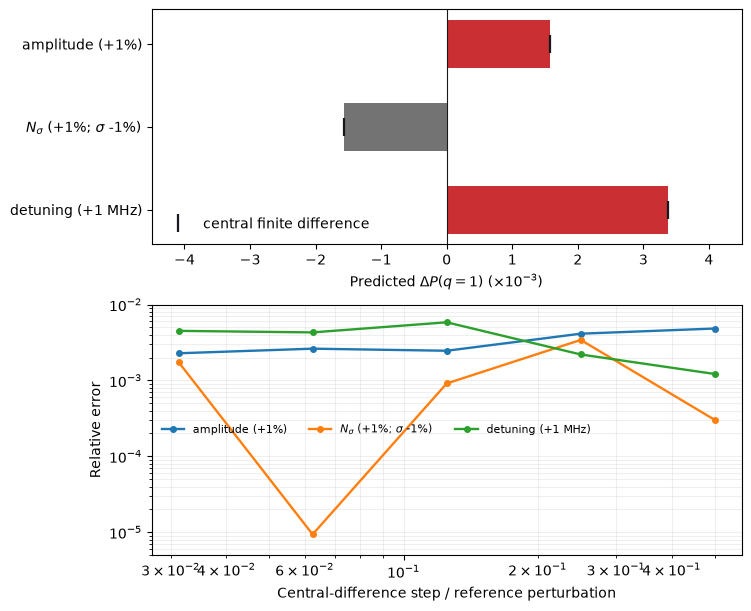

In [12]:
impact_milliprobability = np.asarray(gradient) * 1.0e3
finite_difference_check = np.asarray(finite_differences[0]) * 1.0e3
positions = np.arange(len(perturbation_labels))

figure, (impact_axis, convergence_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 6.0),
    height_ratios=(1.5, 1.6),
    layout="constrained",
)

impact_axis.barh(
    positions,
    impact_milliprobability,
    color=["#C92F33" if value >= 0.0 else "0.45" for value in impact_milliprobability],
    height=0.58,
)
impact_axis.plot(
    finite_difference_check,
    positions,
    linestyle="none",
    marker="|",
    color="#16181C",
    markersize=13,
    markeredgewidth=1.6,
    label="central finite difference",
)
impact_axis.axvline(0.0, color="#16181C", linewidth=0.8)
impact_axis.set(
    yticks=positions,
    yticklabels=perturbation_labels,
    xlabel=r"Predicted $\Delta P(q=1)$ ($\times 10^{-3}$)",
    xlim=(-4.5, 4.5),
)
impact_axis.invert_yaxis()
impact_axis.legend(frameon=False, loc="lower left")

for index, label in enumerate(perturbation_labels):
    convergence_axis.loglog(
        np.asarray(steps),
        np.asarray(relative_errors[:, index]),
        marker="o",
        linewidth=1.7,
        markersize=4.0,
        label=label,
    )
convergence_axis.set(
    xlabel="Central-difference step / reference perturbation",
    ylabel="Relative error",
    ylim=(5.0e-6, 1.0e-2),
)
convergence_axis.grid(alpha=0.2, which="both")
convergence_axis.legend(frameon=False, ncols=3, fontsize=8)

figure_path = "../docs/images/differentiate_a_driven_chip.png"
figure.savefig(figure_path, dpi=180)
plt.show()

```{figure} ../images/differentiate_a_driven_chip.png
:width: 720px
:alt: Driven-qubit sensitivities with finite-difference convergence below

The top panel puts each derivative on its named reference scale. The bottom
panel checks convergence of the central differences.
```

## Losses through multi-sequence analysis

A calibration objective often combines several experiments that share the
same device and control parameters. Each sequence below has a different fixed
pulse duration and carrier offset. All three rebind the same qubit frequency,
amplitude scale, and carrier correction.

In [13]:
experiment_settings = (
    (18.0, 0.020, -0.004),
    (28.0, 0.026, 0.000),
    (40.0, 0.029, 0.004),
)
experiments = []
for duration, amplitude, carrier_offset in experiment_settings:
    experiment = QuantumSequence(chip)
    experiment.schedule(
        drive,
        envelope=Gaussian(duration=duration, sigmas=3.0, amplitude=amplitude),
        freq=frequency0 + carrier_offset,
    )
    experiments.append(experiment)

shared_names = ("q.freq", "amplitude scale", "carrier correction")
shared_origin = jnp.array([frequency0, 1.0, 0.0])
multi_times = jnp.linspace(0.0, 60.0, 81)


def experiment_outputs(shared):
    qubit_frequency, amplitude_scale, carrier_correction = shared
    values = []
    for experiment, (_, nominal_amplitude, nominal_offset) in zip(
        experiments, experiment_settings
    ):
        rebound = experiment.with_params(
            {
                "q.freq": qubit_frequency,
                "pulse.0.amplitude": nominal_amplitude * amplitude_scale,
                "pulse.0.freq": frequency0 + nominal_offset + carrier_correction,
            }
        )
        result = rebound.simulate(
            tlist=multi_times,
            initial_state={"q": 0},
            check_truncation=False,
            partition=False,
        )
        values.append(jnp.real(result.population("q", level=1)[-1]))
    return jnp.stack(values)


reference_outputs = experiment_outputs(shared_origin)
multi_targets = jax.lax.stop_gradient(
    reference_outputs + jnp.array([0.010, -0.015, 0.005])
)
experiment_weights = jnp.array([1.0, 2.0, 0.5])


def multi_residual(shared):
    return experiment_outputs(shared) - multi_targets


def multi_loss(shared):
    return jnp.sum(experiment_weights * multi_residual(shared) ** 2)


multi_jacobian = jax.jacrev(multi_residual)(shared_origin)
multi_loss_gradient = jax.grad(multi_loss)(shared_origin)

{
    "experiments": len(experiments),
    "shared_parameters": shared_names,
    "residual_shape": multi_residual(shared_origin).shape,
    "jacobian_shape": multi_jacobian.shape,
    "jacobian_by_experiment": multi_jacobian,
    "joint_loss_gradient": multi_loss_gradient,
}

{'experiments': 3,
 'shared_parameters': ('q.freq', 'amplitude scale', 'carrier correction'),
 'residual_shape': (3,),
 'jacobian_shape': (3, 3),
 'jacobian_by_experiment': Array([[ -0.63212694,   0.3771558 ,   0.63212694],
        [ -0.79642264,   0.89604468,   0.79642264],
        [ 11.59017361,   0.17943505, -11.59017361]], dtype=float64),
 'joint_loss_gradient': Array([-0.09309369,  0.04532239,  0.09309369], dtype=float64)}

<!-- executed-output:start -->

Output:

```text
{'experiments': 3,
 'shared_parameters': ('q.freq', 'amplitude scale', 'carrier correction'),
 'residual_shape': (3,),
 'jacobian_shape': (3, 3),
 'jacobian_by_experiment': Array([[ -0.63212694,   0.3771558 ,   0.63212694],
        [ -0.79642264,   0.89604468,   0.79642264],
        [ 11.59017361,   0.17943505, -11.59017361]], dtype=float64),
 'joint_loss_gradient': Array([-0.09309369,  0.04532239,  0.09309369], dtype=float64)}
```

<!-- executed-output:end -->

Rows of the Jacobian belong to experiments; columns belong to shared physical
parameters. The weighted scalar loss contracts those rows into one gradient.
Keep the Jacobian when diagnosing which experiment constrains which parameter,
and use the loss gradient for an optimization step.

The receipt puts all three derivatives on their reference-perturbation scales
and records the worst relative disagreement across the finite-difference
steps. Only first derivatives are checked here.

In [14]:
reference_result = sequence.simulate(
    tlist=times,
    initial_state={"q": 0},
    check_truncation=False,
    partition=False,
)

gradient_receipt = {
    "backend": "dynamiqs",
    "base_population": float(population0),
    "figure": figure_path,
    "first_order_only": True,
    "fixed_structure_during_trace": True,
    "gradient_per_reference_perturbation": {
        path: float(value) for path, value in zip(parameter_paths, gradient)
    },
    "maximum_relative_error_across_steps": float(np.max(relative_errors)),
    "multi_sequence_count": len(experiments),
    "multi_sequence_jacobian_shape": list(multi_jacobian.shape),
    "multi_sequence_loss_gradient": [float(value) for value in multi_loss_gradient],
    "original_sequence_unchanged": dict(sequence.parameters)
    == {
        "q.freq": frequency0,
        "q.anharmonicity": -0.30,
        "pulse.0.freq": frequency0,
        "pulse.0.phase": 0.0,
        "pulse.0.start_time": None,
        "pulse.0.duration": 40.0,
        "pulse.0.sigmas": sigmas0,
        "pulse.0.amplitude": amplitude0,
    },
    "parameter_paths": list(parameter_paths),
    "solver": reference_result.solver,
}

print(f"RESULT gradient={json.dumps(gradient_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT gradient={"backend":"dynamiqs","base_population":0.99551809283684,"figure":"../docs/images/differentiate_a_driven_chip.png","first_order_only":true,"fixed_structure_during_trace":true,"gradient_per_reference_perturbation":{"pulse.0.amplitude":0.0015761406257590448,"pulse.0.freq":0.003378107041808197,"pulse.0.sigmas":-0.001567228852927645},"maximum_relative_error_across_steps":0.005832718427203168,"multi_sequence_count":3,"multi_sequence_jacobian_shape":[3,3],"multi_sequence_loss_gradient":[-0.09309368743280567,0.0453223899145748,0.0930936874328054],"original_sequence_unchanged":true,"parameter_paths":["pulse.0.amplitude","pulse.0.sigmas","pulse.0.freq"],"solver":"sesolve"}


<!-- executed-output:start -->

Output:

```text
RESULT gradient={"backend":"dynamiqs","base_population":0.99551809283684,"figure":"../docs/images/differentiate_a_driven_chip.png","first_order_only":true,"fixed_structure_during_trace":true,"gradient_per_reference_perturbation":{"pulse.0.amplitude":0.0015761406257590448,"pulse.0.freq":0.003378107041808197,"pulse.0.sigmas":-0.001567228852927645},"maximum_relative_error_across_steps":0.005832718427203168,"multi_sequence_count":3,"multi_sequence_jacobian_shape":[3,3],"multi_sequence_loss_gradient":[-0.09309368743280567,0.0453223899145748,0.0930936874328054],"original_sequence_unchanged":true,"parameter_paths":["pulse.0.amplitude","pulse.0.sigmas","pulse.0.freq"],"solver":"sesolve"}
```

<!-- executed-output:end -->

## Boundaries of this gradient

The traced calculation keeps the device graph, Hilbert-space dimensions, and
RWA band selection fixed. dynamiqs supports this automatic-differentiation
path; QuTiP remains available for ordinary solves and sweeps but does not
provide gradients. Eigenvector derivatives require care near degenerate
subspaces. Gradients inherit the solver tolerances, local-basis
truncation, frame, approximation, and loss scaling chosen for the forward
calculation.

Replace the population residuals with the observables that define the
experiment. Use `jax.grad` for a scalar loss and `jax.jacrev` or `jax.jacfwd`
for a vector of residuals or traces. Keep named parameters, explicit scales,
and an independent finite-difference spot check when introducing a new path.